<a href="https://colab.research.google.com/github/Faizantinwala007/AI-Energy-Forecasting/blob/main/AI_Energy_Forecasting_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(1) **MAIN TITLE**


# ⚡ AI-Powered Energy Consumption Forecasting System

## 📌 Objective
Predict future electricity usage using Machine Learning based on historical energy data.

## 🏭 Industry Use Case
Used in smart grids, smart cities, industries, and data centers to optimize energy usage.


(2) **IMPORT LIBRARIES**

In [ ]:
# Import all required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

🔷 3. Create Dataset (Simulated)

In [ ]:
# Create sample energy consumption dataset

np.random.seed(42)

data = np.arange(200) + np.random.normal(0, 5, 200)

df = pd.DataFrame(data, columns=["energy"])

df.head()

,energy
0,2.483571
1,0.308678
2,5.238443
3,10.615149
4,2.829233


🔷 4. Visualize Dataset

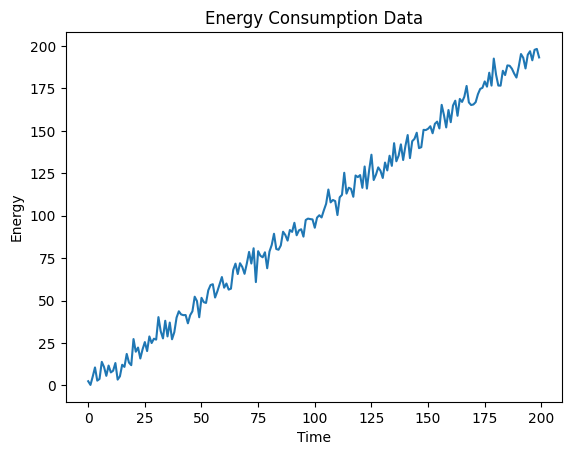

In [ ]:
# Plot dataset

plt.plot(df["energy"])
plt.title("Energy Consumption Data")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.show()

🔷 5. Data Normalization

In [ ]:
# Scale data between 0 and 1

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(df)

🔷 6. Create Time Sequences

In [ ]:
# Convert data into sequences for LSTM

def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

seq_length = 10

X, y = create_sequences(data_scaled, seq_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (190, 10, 1)
y shape: (190, 1)


🔷 7. Train-Test Split

In [ ]:
# Split data without shuffling (important for time series)

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

🔷 8. Build LSTM Model

In [ ]:
# Build LSTM model

model = Sequential()

model.add(LSTM(50, input_shape=(seq_length, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🔷 9. Train Model

In [ ]:
# Train model

history = model.fit(X_train, y_train, epochs=10)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1849
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0947
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0310
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0057
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0116
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0087
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0031
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0036
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025


🔷 10. Make Predictions

In [ ]:
# Predict future values

predictions = model.predict(X_test)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


🔷 11. Visualize Predictions

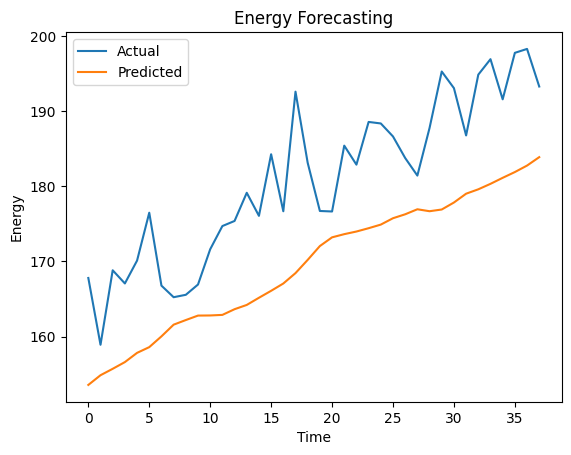

In [ ]:
# Plot actual vs predicted

plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.title("Energy Forecasting")
plt.xlabel("Time")
plt.ylabel("Energy")

plt.legend()
plt.show()

🔷 12. Predict Future Value

In [ ]:
# Predict next value

last_sequence = X_test[-1]

last_sequence = last_sequence.reshape(1, seq_length, 1)

future_prediction = model.predict(last_sequence)

future_prediction = scaler.inverse_transform(future_prediction)

print("Next Predicted Value:", future_prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Next Predicted Value: 183.88022


🔷 13. Conclusion

In [ ]:
# Conclusion:
# - Model successfully predicts future energy consumption
# - LSTM captures time-based patterns
# - Can be used in smart grids and energy systems